# Task 1: Derivative and Slope Intuition

Function:
f(x) = x² + 2x + 1

Goal:
- Compute derivatives
- Plot function
- Plot tangent lines
- Analyze slope behavior

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return x**2 + 2*x + 1

def derivative(x):
    return 2*x + 2

In [3]:
points = [-2, 0, 3]

for p in points:
    print(
        f"x={p}, "
        f"f(x)={f(p)}, "
        f"derivative={derivative(p)}"
    )

x=-2, f(x)=1, derivative=-2
x=0, f(x)=1, derivative=2
x=3, f(x)=16, derivative=8


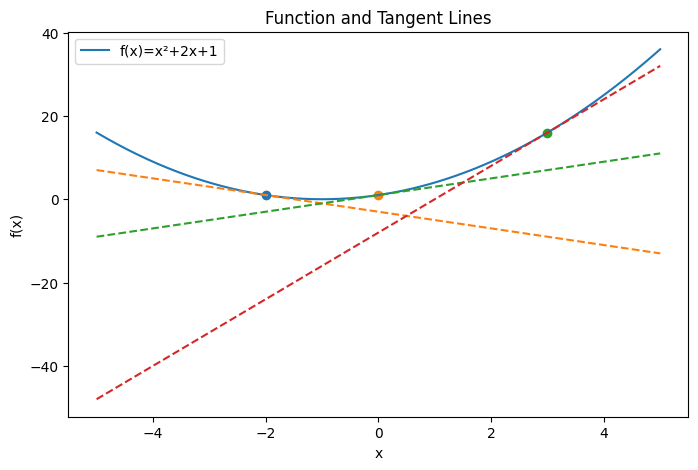

In [4]:
x = np.linspace(-5,5,500)

plt.figure(figsize=(8,5))
plt.plot(x,f(x),label="f(x)=x²+2x+1")

for p in points:

    y_point = f(p)

    slope = derivative(p)

    tangent = slope*(x-p)+y_point

    plt.plot(x,tangent,"--")

    plt.scatter(p,y_point)

plt.title("Function and Tangent Lines")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()

plt.savefig("../visuals/task1_derivative.png")

plt.show()

## Observations

1. At x = -2 the derivative is negative, so the function decreases.

2. At x = 0 the derivative becomes positive, so the function increases.

3. Larger positive derivatives indicate steeper growth. In machine learning, gradients guide optimization toward minima.

# Task 2: Gradient Descent Mini Experiment

In [5]:
import pandas as pd

In [6]:
def loss(theta):
    return (theta-3.5)**2 + 1

def grad(theta):
    return 2*(theta-3.5)

In [7]:
theta = 10
lr = 0.15

history = []

In [8]:
for i in range(20):

    l = loss(theta)

    g = grad(theta)

    history.append([i,theta,l,g])

    theta = theta - lr*g

In [9]:
df = pd.DataFrame(
    history,
    columns=[
        "Iteration",
        "Theta",
        "Loss",
        "Gradient"
    ]
)

df.head()

,Iteration,Theta,Loss,Gradient
0,0,10.00000,43.250000,13.0000
1,1,8.05000,21.702500,9.1000
2,2,6.68500,11.144225,6.3700
3,3,5.72950,5.970670,4.4590
4,4,5.06065,3.435628,3.1213


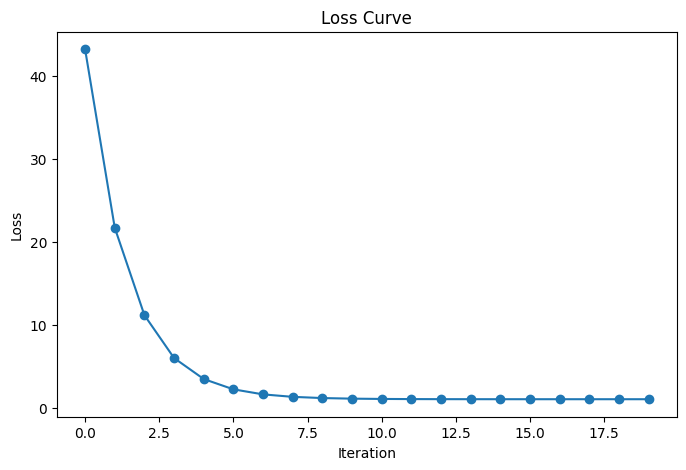

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Iteration"],
    df["Loss"],
    marker="o"
)

plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.savefig("../visuals/task2_loss_curve.png")

plt.show()

## Learning Rate Comparison

Learning Rate = 0.01
- Converges slowly.

Learning Rate = 0.15
- Balanced convergence.

Learning Rate = 0.50
- Fast convergence but may overshoot in complex problems.*

# Task 3: Probability Basics with Sampled Data

In [11]:
uniform_data = np.random.uniform(
    0,
    100,
    1000
)

normal_data = np.random.normal(
    50,
    15,
    1000
)

In [12]:
print("Uniform Mean:", np.mean(uniform_data))
print("Uniform Std:", np.std(uniform_data))

print("Normal Mean:", np.mean(normal_data))
print("Normal Std:", np.std(normal_data))

Uniform Mean: 51.48767148732342
Uniform Std: 29.57773911403649
Normal Mean: 49.83863229640109
Normal Std: 14.83681417834879


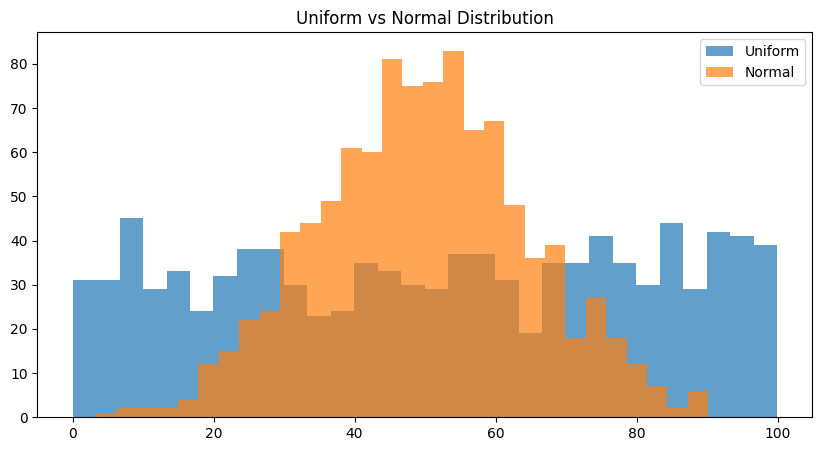

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    uniform_data,
    bins=30,
    alpha=0.7,
    label="Uniform"
)

plt.hist(
    normal_data,
    bins=30,
    alpha=0.7,
    label="Normal"
)

plt.legend()

plt.title("Uniform vs Normal Distribution")

plt.savefig("../visuals/task3_histograms.png")

plt.show()

## Interpretation

Uniform Distribution:
- Values spread evenly.

Normal Distribution:
- Values cluster around the mean.

The normal distribution forms a bell-shaped curve while the uniform distribution distributes probability more evenly.

# Task 4: Full EDA on California Housing Dataset

In [17]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
df.shape

(20640, 9)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [20]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [21]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

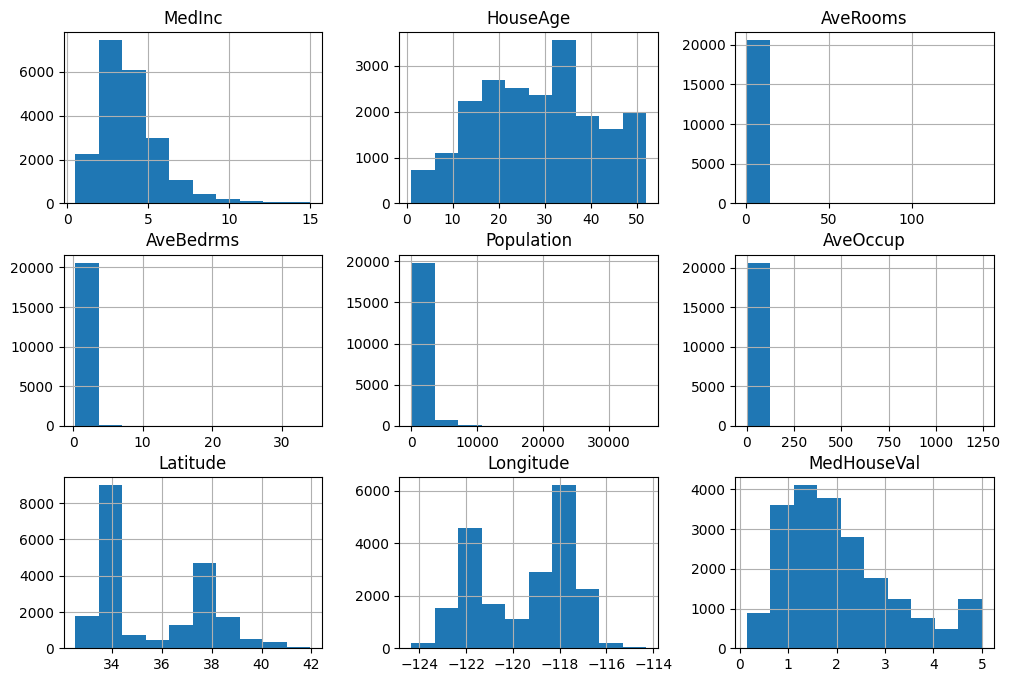

In [22]:
df.hist(figsize=(12,8))
plt.savefig("../visuals/housing_histogram.png")
plt.show()

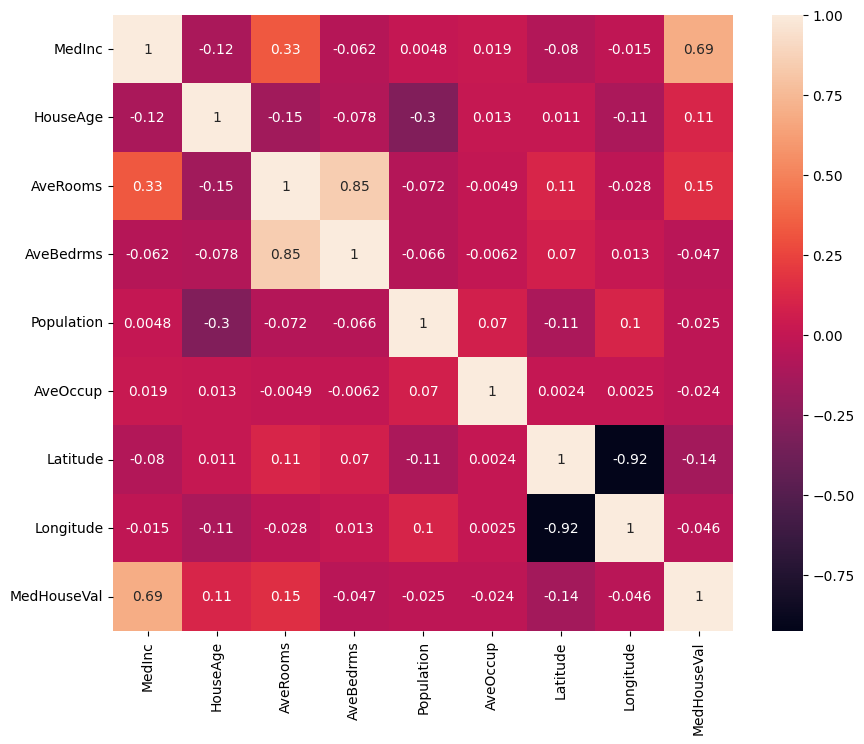

In [23]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.savefig("../visuals/housing_heatmap.png")

plt.show()

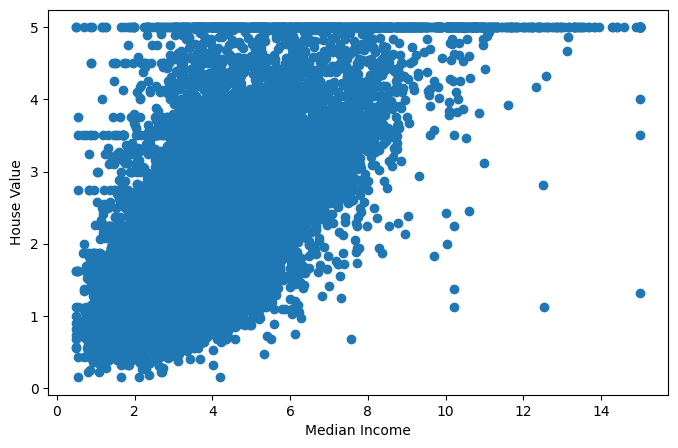

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"]
)

plt.xlabel("Median Income")
plt.ylabel("House Value")

plt.savefig("../visuals/housing_scatter.png")

plt.show()

## EDA Insights

1. Median income has a strong positive relationship with house value.

2. Most variables are skewed and not perfectly normally distributed.

3. High-income regions generally have higher house prices.